# Experiment: codex
## 0 Setup

This notebook implements the full modelling workflow for arts participation prediction, with fixed random seed control for reproducibility.

In [1]:
import os
import random
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Reproducibility controls
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["MPLCONFIGDIR"] = str(Path(".mplconfig"))
Path(".mplconfig").mkdir(exist_ok=True)

# Paths (relative only)
DATA_DIR = Path("data")
EVIDENCE_DIR = Path("evidence_codex")
EDA_PICS_DIR = EVIDENCE_DIR / "EDA_codex_Pics"
EVIDENCE_DIR.mkdir(exist_ok=True)
EDA_PICS_DIR.mkdir(exist_ok=True)

print("Setup complete. RANDOM_STATE=42")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Evidence directory: {EVIDENCE_DIR.resolve()}")

Setup complete. RANDOM_STATE=42
Data directory: /Users/c47b07/Documents/UCL/Term 2/Predictive Analytics/PA_group/agents/codex/data
Evidence directory: /Users/c47b07/Documents/UCL/Term 2/Predictive Analytics/PA_group/agents/codex/evidence_codex


# 1 Data Understanding
## 1.1 Dataset Ingestion and Schema Checks

This subsection loads the raw dataset into `participation_raw`, reports its shape, and checks the expected variables and obvious schema properties.

In [2]:
data_path = DATA_DIR / "participation_2024-25_experiment_v2.tab"
participation_raw = pd.read_csv(data_path, sep="	")
print("participation_raw shape:", participation_raw.shape)

required_vars = [
    "CARTS_NET", "CHERVIS12_NET", "EDUCAT3", "NSSEC_3", "FINHARD", "WELLB1",
    "CINTOFT", "CSMARTD_Count", "WELLB4", "TENHARM", "LONELY", "ETHNIC_NET",
    "emdidc19", "CULTSATIS", "SEX", "AGEBAND"
]

missing_vars = [c for c in required_vars if c not in participation_raw.columns]
extra_vars = [c for c in participation_raw.columns if c not in required_vars]

print("Missing required variables:", missing_vars if missing_vars else "None")
print("Unexpected extra variables:", extra_vars if extra_vars else "None")

schema_issues = []
for col in required_vars:
    if col in participation_raw.columns and participation_raw[col].isna().any():
        schema_issues.append(f"{col}: contains NaN")

print()
print("Dtypes:")
print(participation_raw[required_vars].dtypes)

print()
print("Null counts (expected 0 due coded missing):")
print(participation_raw[required_vars].isna().sum())

if schema_issues:
    print()
    print("Schema issues detected:")
    for issue in schema_issues:
        print("-", issue)
else:
    print()
    print("No obvious schema issues for this step.")

participation_raw shape: (34378, 16)
Missing required variables: None
Unexpected extra variables: None

Dtypes:
CARTS_NET        int64
CHERVIS12_NET    int64
EDUCAT3          int64
NSSEC_3          int64
FINHARD          int64
WELLB1           int64
CINTOFT          int64
CSMARTD_Count    int64
WELLB4           int64
TENHARM          int64
LONELY           int64
ETHNIC_NET       int64
emdidc19         int64
CULTSATIS        int64
SEX              int64
AGEBAND          int64
dtype: object

Null counts (expected 0 due coded missing):
CARTS_NET        0
CHERVIS12_NET    0
EDUCAT3          0
NSSEC_3          0
FINHARD          0
WELLB1           0
CINTOFT          0
CSMARTD_Count    0
WELLB4           0
TENHARM          0
LONELY           0
ETHNIC_NET       0
emdidc19         0
CULTSATIS        0
SEX              0
AGEBAND          0
dtype: int64

No obvious schema issues for this step.


## 1.2 Problem Definition

**Prediction task**: Binary classification to predict whether a respondent was under-engaged with physical arts in the last 12 months.

We frame this as an under-engagement identification problem with social research value. The objective is to identify potentially underserved groups across demographic, socioeconomic, digital, and geographic dimensions, supporting inclusive policy and engagement strategy.

- **Target variable**: `CARTS_NET`
- **Feature variables**: `CHERVIS12_NET, EDUCAT3, NSSEC_3, FINHARD, WELLB1, CINTOFT, CSMARTD_Count, WELLB4, TENHARM, LONELY, ETHNIC_NET, emdidc19, CULTSATIS, SEX, AGEBAND`

Rows with target values `-3` and `3` are treated as missing target information and will be dropped later to create the binary classification sample.

| Variable | Role | Description (from dictionary) |
|---|---|---|
| CARTS_NET | Target | Physical arts engagement in last 12 months |
| CHERVIS12_NET | Feature | Heritage/historic site visit in last 12 months |
| EDUCAT3 | Feature | Highest qualification level |
| NSSEC_3 | Feature | Socio-economic class |
| FINHARD | Feature | Financial difficulty status |
| WELLB1 | Feature | Life satisfaction (0-10) |
| CINTOFT | Feature | Internet usage frequency |
| CSMARTD_Count | Feature | Number of smart device types in household |
| WELLB4 | Feature | Anxiety yesterday (0-10) |
| TENHARM | Feature | Housing tenure status |
| LONELY | Feature | Loneliness frequency |
| ETHNIC_NET | Feature | Ethnic group |
| emdidc19 | Feature | Area deprivation decile (1 most deprived, 10 least) |
| CULTSATIS | Feature | Satisfaction with local cultural offer |
| SEX | Feature | Gender |
| AGEBAND | Feature | Age band |

# 2 Exploratory Data Analysis

This section creates the EDA analysis sample, performs exploratory summaries, and saves visualisations to `evidence_codex/EDA_codex_Pics`.

In [3]:
# Convert target to binary sample by removing coded-missing target rows
participation_model_base = participation_raw.loc[
    ~participation_raw["CARTS_NET"].isin([-3, 3])
].copy()

# Create EDA dataframe for subsequent steps
# Keep non-0/1 coding at this stage through descriptive labels
participation_eda = participation_model_base.drop(columns=["CARTS_NET"]).copy()
participation_eda["participation_eda"] = participation_model_base["CARTS_NET"].map({1: "Engaged", 2: "UnderEngaged"})

print("Rows before target filtering:", len(participation_raw))
print("Rows after target filtering:", len(participation_eda))
print("Target distribution (EDA target):")
print(participation_eda["participation_eda"].value_counts())

Rows before target filtering: 34378
Rows after target filtering: 34338
Target distribution (EDA target):
participation_eda
Engaged         31290
UnderEngaged     3048
Name: count, dtype: int64


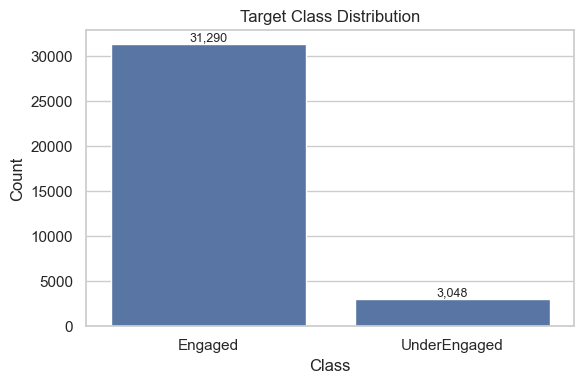

<Figure size 1000x400 with 0 Axes>

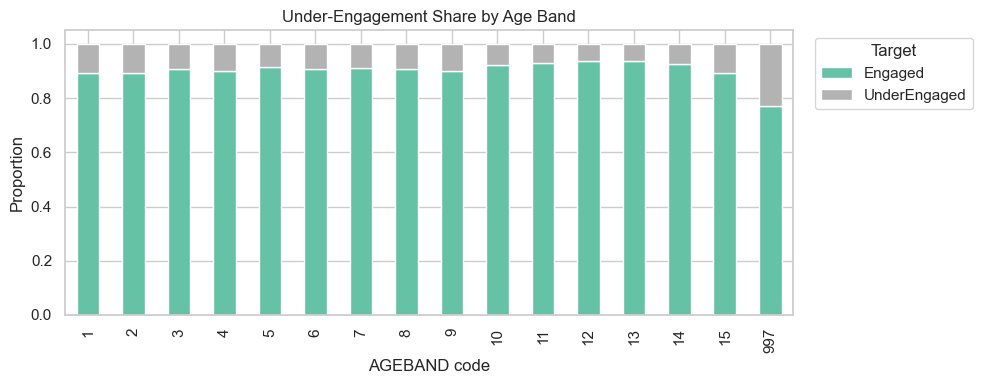

<Figure size 800x400 with 0 Axes>

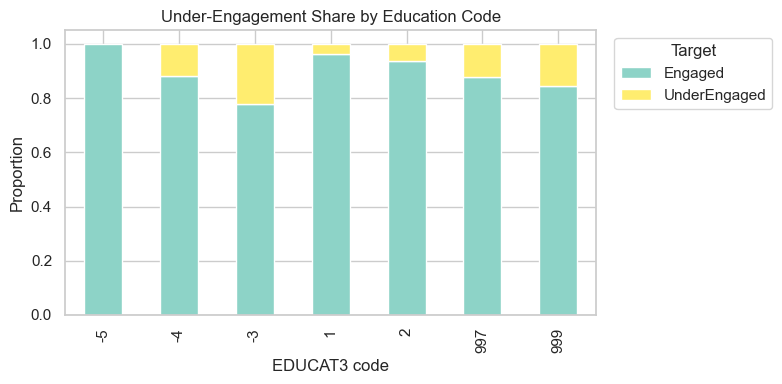

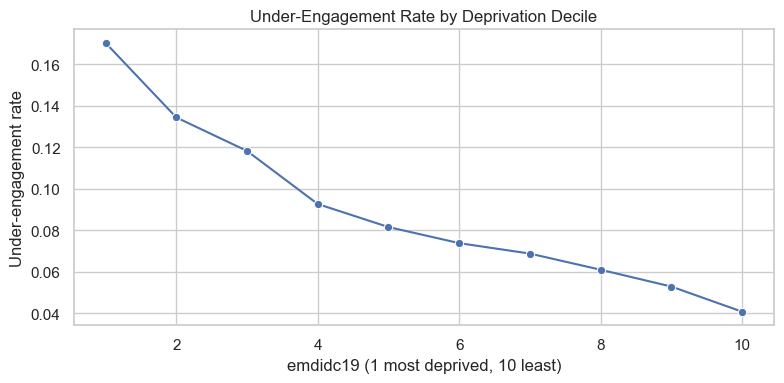

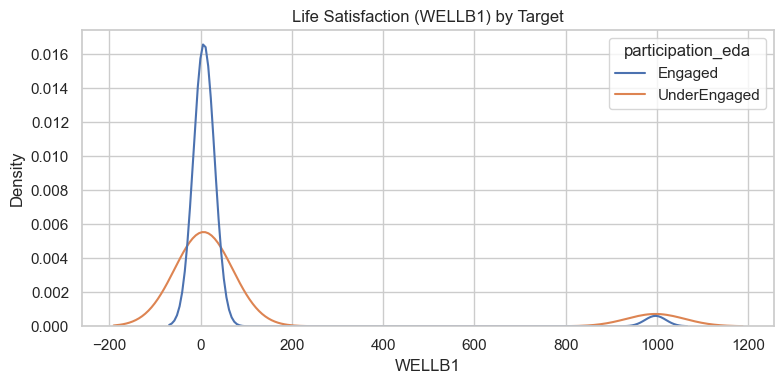

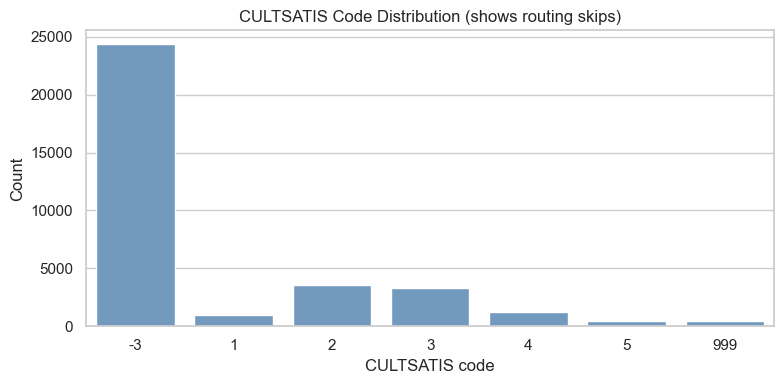

EDA figures saved to: evidence_codex/EDA_codex_Pics


In [4]:
sns.set_theme(style="whitegrid")

# Plot 1: target distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=participation_eda, x="participation_eda", order=["Engaged", "UnderEngaged"])
ax.set_title("Target Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(EDA_PICS_DIR / "01_target_distribution.png", dpi=150)
plt.show()

# Plot 2: age band by target
age_order = sorted([x for x in participation_eda["AGEBAND"].unique() if x > 0])
plt.figure(figsize=(10, 4))
age_ct = pd.crosstab(participation_eda["AGEBAND"], participation_eda["participation_eda"], normalize="index")
age_ct = age_ct.reindex(age_order)
age_ct.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="Set2")
plt.title("Under-Engagement Share by Age Band")
plt.xlabel("AGEBAND code")
plt.ylabel("Proportion")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(EDA_PICS_DIR / "02_ageband_target_stacked.png", dpi=150)
plt.show()

# Plot 3: education by target
plt.figure(figsize=(8, 4))
edu_ct = pd.crosstab(participation_eda["EDUCAT3"], participation_eda["participation_eda"], normalize="index")
edu_ct.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set3")
plt.title("Under-Engagement Share by Education Code")
plt.xlabel("EDUCAT3 code")
plt.ylabel("Proportion")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(EDA_PICS_DIR / "03_education_target_stacked.png", dpi=150)
plt.show()

# Plot 4: deprivation decile vs under-engagement rate
depr = participation_eda.copy()
depr["is_under"] = (depr["participation_eda"] == "UnderEngaged").astype(int)
depr_rate = depr.groupby("emdidc19", as_index=False)["is_under"].mean()
plt.figure(figsize=(8, 4))
sns.lineplot(data=depr_rate, x="emdidc19", y="is_under", marker="o")
plt.title("Under-Engagement Rate by Deprivation Decile")
plt.xlabel("emdidc19 (1 most deprived, 10 least)")
plt.ylabel("Under-engagement rate")
plt.tight_layout()
plt.savefig(EDA_PICS_DIR / "04_deprivation_underengagement_line.png", dpi=150)
plt.show()

# Plot 5: wellbeing distribution by target
plt.figure(figsize=(8, 4))
sns.kdeplot(data=participation_eda[participation_eda["WELLB1"] >= 0], x="WELLB1", hue="participation_eda", common_norm=False)
plt.title("Life Satisfaction (WELLB1) by Target")
plt.xlabel("WELLB1")
plt.tight_layout()
plt.savefig(EDA_PICS_DIR / "05_wellb1_kde_by_target.png", dpi=150)
plt.show()

# Plot 6: culture satisfaction coding profile
plt.figure(figsize=(8, 4))
cult_counts = participation_eda["CULTSATIS"].value_counts().sort_index()
sns.barplot(x=cult_counts.index.astype(str), y=cult_counts.values, color="#6699CC")
plt.title("CULTSATIS Code Distribution (shows routing skips)")
plt.xlabel("CULTSATIS code")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(EDA_PICS_DIR / "06_cultsatis_distribution.png", dpi=150)
plt.show()

print("EDA figures saved to:", EDA_PICS_DIR)

# 3 Missingness Handling

Missingness is represented by coded values rather than `NaN`. Rules were set feature-by-feature using the data dictionary meanings and missing rates:

- For coded non-informative values with low rate (<5%), rows are dropped.
- For higher-rate coded non-informative values, values are retained as explicit `Unknown` category to avoid large row loss.
- For `CULTSATIS`, `-3` is treated as informative (`RoutingSkip`) rather than missing.
- For `EDUCAT3`, `-3` means `NoQualifications` and is retained as informative.

In [5]:
feature_cols = [
    "CHERVIS12_NET", "EDUCAT3", "NSSEC_3", "FINHARD", "WELLB1", "CINTOFT",
    "CSMARTD_Count", "WELLB4", "TENHARM", "LONELY", "ETHNIC_NET", "emdidc19",
    "CULTSATIS", "SEX", "AGEBAND"
]
coded_missing = {-5, -4, -3, 997, 999}

missing_profile = []
for col in feature_cols:
    rate = participation_eda[col].isin(coded_missing).mean()
    missing_profile.append({"feature": col, "coded_missing_rate": rate})
missing_profile_df = pd.DataFrame(missing_profile).sort_values("coded_missing_rate", ascending=False)
display(missing_profile_df)

missing_profile_df.to_csv(EVIDENCE_DIR / "missingness_profile.csv", index=False)

,feature,coded_missing_rate
12,CULTSATIS,0.721533
1,EDUCAT3,0.239938
2,NSSEC_3,0.148553
5,CINTOFT,0.059089
6,CSMARTD_Count,0.058856
3,FINHARD,0.048110
7,WELLB4,0.045489
4,WELLB1,0.044295
9,LONELY,0.036752
10,ETHNIC_NET,0.031539


In [6]:
rows_before = len(participation_eda)
clean = participation_eda.copy()

# Low-rate non-informative codes -> drop rows
low_missing_drop_codes = {
    "EDUCAT3": {-4, -5, 997, 999},
    "FINHARD": {-3, -4, -5, 997},
    "WELLB1": {-4, -5, 997},
    "WELLB4": {-4, -5, 997},
    "TENHARM": {-3},
    "LONELY": {-4, -5, 997},
    "ETHNIC_NET": {-3, 997, 999},
    "CULTSATIS": {999},
    "SEX": {-4, -5, 997},
    "AGEBAND": {-3, 997},
}

dropped_by_rule = {}
for col, bad_codes in low_missing_drop_codes.items():
    before = len(clean)
    clean = clean.loc[~clean[col].isin(bad_codes)].copy()
    dropped_by_rule[col] = before - len(clean)

# High-rate non-informative codes -> keep as explicit Unknown category
high_missing_recode = {
    "NSSEC_3": {-3: "Unknown"},
    "CINTOFT": {-3: "Unknown", -4: "Unknown", -5: "Unknown"},
    "CSMARTD_Count": {-3: "Unknown"},
}
for col, mapping in high_missing_recode.items():
    clean[col] = clean[col].replace(mapping)

# Variable-specific informative recoding
clean["CULTSATIS"] = clean["CULTSATIS"].replace({-3: "RoutingSkip"})
clean["EDUCAT3"] = clean["EDUCAT3"].replace({-3: "NoQualifications"})

# Create final binary target for modelling: 1 = UnderEngaged, 0 = Engaged
clean["participation_target"] = (clean["participation_eda"] == "UnderEngaged").astype(int)
clean = clean.drop(columns=["participation_eda"])

participation_clean = clean.copy()

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", len(participation_clean))
print("Rows dropped:", rows_before - len(participation_clean))
print()
print("Rows dropped per low-missing rule:")
print(pd.Series(dropped_by_rule).sort_values(ascending=False))

print()
print("Any NaN remaining:", participation_clean.isna().sum().sum())

participation_clean.to_csv(EVIDENCE_DIR / "participation_clean.csv", index=False)
print("Saved cleaned data to", EVIDENCE_DIR / "participation_clean.csv")

Rows before cleaning: 34338
Rows after cleaning: 28995
Rows dropped: 5343

Rows dropped per low-missing rule:
FINHARD       1553
EDUCAT3       1111
WELLB1         880
ETHNIC_NET     540
WELLB4         318
CULTSATIS      279
SEX            257
LONELY         188
AGEBAND        175
TENHARM         42
dtype: int64

Any NaN remaining: 0
Saved cleaned data to evidence_codex/participation_clean.csv


# 4 Modelling Setup
## 4.1 Prepare Modelling Data

This section defines `X` and `y`, builds preprocessing pipelines for Logistic Regression and XGBoost, and creates fixed stratified train/validation/test splits (0.70/0.15/0.15).

In [7]:
X = participation_clean.drop(columns=["participation_target"]).copy()
y = participation_clean["participation_target"].copy()

# Treat coded ordinal/nominal variables as categorical except explicit scales
numeric_cols = ["WELLB1", "WELLB4", "emdidc19"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

# Ensure categorical columns are strings for stable encoding
for col in categorical_cols:
    X[col] = X[col].astype(str)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Split sizes:")
print(f"Train: {X_train.shape}, y positive rate={y_train.mean():.4f}")
print(f"Val:   {X_val.shape}, y positive rate={y_val.mean():.4f}")
print(f"Test:  {X_test.shape}, y positive rate={y_test.mean():.4f}")

preprocess_lr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

preprocess_xgb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"Estimated scale_pos_weight from training split: {scale_pos_weight:.3f}")

Split sizes:
Train: (20296, 15), y positive rate=0.0695
Val:   (4349, 15), y positive rate=0.0694
Test:  (4350, 15), y positive rate=0.0697
Estimated scale_pos_weight from training split: 13.394


## 4.2 Create Evaluation Harness

The harness uses common metrics for both models:

- Primary selection metric: **F2 score** (recall-weighted, aligns with identifying under-engaged groups)
- Supporting discrimination metrics: **PR-AUC**, **ROC-AUC**
- Operating-point metrics: **precision**, **recall**, **F1**, **specificity**, **balanced accuracy**
- Confusion matrix counts for policy-facing error interpretation

Threshold tuning is performed on validation probabilities only; test data is reserved for final comparison.

In [8]:
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "specificity": specificity,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def find_best_threshold(y_true, y_prob, metric="f2"):
    thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for t in thresholds:
        row = evaluate_predictions(y_true, y_prob, threshold=t)
        rows.append(row)
    df = pd.DataFrame(rows)
    best_idx = df[metric].idxmax()
    return float(df.loc[best_idx, "threshold"]), df

## 4.3 Baseline Logistic Regression

In [9]:
baseline_lr = Pipeline(
    steps=[
        ("preprocess", preprocess_lr),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_lr.fit(X_train, y_train)
val_prob_baseline = baseline_lr.predict_proba(X_val)[:, 1]
baseline_val_metrics = evaluate_predictions(y_val, val_prob_baseline, threshold=0.5)
baseline_val_metrics["model"] = "baseline_lr"

baseline_val_df = pd.DataFrame([baseline_val_metrics])
display(baseline_val_df[["model", "threshold", "f2", "recall", "precision", "pr_auc", "roc_auc", "balanced_accuracy"]])

,model,threshold,f2,recall,precision,pr_auc,roc_auc,balanced_accuracy
0,baseline_lr,0.5,0.119427,0.099338,0.625,0.356774,0.847848,0.547445


# 5 Model Development and Selection
## 5.1 Improve Logistic Regression

Logistic Regression is tuned on the validation set only, using fixed train/validation/test splits and threshold optimisation for F2.

In [10]:
lr_param_grid = {
    "C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
}

lr_trials = []
trial_id = 0

for C in lr_param_grid["C"]:
    for penalty in lr_param_grid["penalty"]:
        for cw in lr_param_grid["class_weight"]:
            trial_id += 1
            model = Pipeline(
                steps=[
                    ("preprocess", preprocess_lr),
                    (
                        "model",
                        LogisticRegression(
                            C=C,
                            penalty=penalty,
                            class_weight=cw,
                            solver="liblinear",
                            max_iter=1000,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            )
            model.fit(X_train, y_train)
            val_prob = model.predict_proba(X_val)[:, 1]
            best_t, threshold_table = find_best_threshold(y_val, val_prob, metric="f2")
            best_row = threshold_table.loc[threshold_table["f2"].idxmax()].to_dict()
            lr_trials.append(
                {
                    "trial": trial_id,
                    "C": C,
                    "penalty": penalty,
                    "class_weight": str(cw),
                    "best_threshold": best_t,
                    **best_row,
                    "model_obj": model,
                }
            )

lr_trials_df = pd.DataFrame(lr_trials).sort_values("f2", ascending=False).reset_index(drop=True)
best_lr_row = lr_trials_df.iloc[0]
tuned_lr = best_lr_row["model_obj"]
tuned_lr_threshold = float(best_lr_row["best_threshold"])

display(lr_trials_df[["trial", "C", "penalty", "class_weight", "best_threshold", "f2", "recall", "precision", "pr_auc", "roc_auc"]].head(10))
print("Best LR threshold:", tuned_lr_threshold)

,trial,C,penalty,class_weight,best_threshold,f2,recall,precision,pr_auc,roc_auc
0,6,0.05,l1,balanced,0.52,0.508621,0.781457,0.212230,0.346240,0.850930
1,10,0.10,l1,balanced,0.54,0.507569,0.754967,0.219653,0.353208,0.851126
2,4,0.01,l2,balanced,0.57,0.506270,0.721854,0.230688,0.347675,0.851287
3,8,0.05,l2,balanced,0.54,0.505118,0.751656,0.218479,0.351677,0.851256
4,12,0.10,l2,balanced,0.55,0.503597,0.741722,0.220472,0.353873,0.851089
5,13,0.50,l1,None,0.08,0.501990,0.751656,0.215575,0.357111,0.848827
6,7,0.05,l2,None,0.08,0.501753,0.758278,0.213222,0.356611,0.849523
7,24,2.00,l2,balanced,0.49,0.501248,0.798013,0.201505,0.352563,0.850602
8,22,2.00,l1,balanced,0.49,0.501248,0.798013,0.201505,0.352429,0.850583
9,28,5.00,l2,balanced,0.49,0.501248,0.798013,0.201505,0.352127,0.850559


Best LR threshold: 0.5199999999999999


## 5.2 Tune XGBoost

In [11]:
xgb_candidates = [
    {"n_estimators": 150, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 1},
    {"n_estimators": 250, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 1},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3},
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.08, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 1},
    {"n_estimators": 250, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 3},
    {"n_estimators": 180, "max_depth": 3, "learning_rate": 0.1, "subsample": 0.9, "colsample_bytree": 0.8, "min_child_weight": 1},
]
xgb_scale_weight_options = [1.0, float(scale_pos_weight)]

xgb_trials = []
trial_id = 0

for params in xgb_candidates:
    for spw in xgb_scale_weight_options:
        trial_id += 1
        model = Pipeline(
            steps=[
                ("preprocess", preprocess_xgb),
                (
                    "model",
                    XGBClassifier(
                        objective="binary:logistic",
                        eval_metric="logloss",
                        random_state=RANDOM_STATE,
                        tree_method="hist",
                        n_jobs=4,
                        scale_pos_weight=spw,
                        **params,
                    ),
                ),
            ]
        )
        model.fit(X_train, y_train)
        val_prob = model.predict_proba(X_val)[:, 1]
        best_t, threshold_table = find_best_threshold(y_val, val_prob, metric="f2")
        best_row = threshold_table.loc[threshold_table["f2"].idxmax()].to_dict()
        xgb_trials.append(
            {
                "trial": trial_id,
                **params,
                "scale_pos_weight": spw,
                "best_threshold": best_t,
                **best_row,
                "model_obj": model,
            }
        )

xgb_trials_df = pd.DataFrame(xgb_trials).sort_values("f2", ascending=False).reset_index(drop=True)
best_xgb_row = xgb_trials_df.iloc[0]
tuned_xgb = best_xgb_row["model_obj"]
tuned_xgb_threshold = float(best_xgb_row["best_threshold"])

display(
    xgb_trials_df[
        [
            "trial", "n_estimators", "max_depth", "learning_rate", "subsample",
            "colsample_bytree", "min_child_weight", "scale_pos_weight",
            "best_threshold", "f2", "recall", "precision", "pr_auc", "roc_auc"
        ]
    ].head(10)
)
print("Best XGBoost threshold:", tuned_xgb_threshold)

,trial,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,scale_pos_weight,best_threshold,f2,recall,precision,pr_auc,roc_auc
0,7,200,4,0.08,0.9,0.9,1,1.000000,0.10,0.517406,0.718543,0.244094,0.340863,0.852314
1,3,250,3,0.05,0.8,0.8,1,1.000000,0.08,0.514546,0.784768,0.216438,0.344591,0.854058
2,4,250,3,0.05,0.8,0.8,1,13.394326,0.57,0.514193,0.731788,0.234857,0.345348,0.853682
3,2,150,3,0.05,0.8,0.8,1,13.394326,0.56,0.513933,0.745033,0.229358,0.345341,0.853745
4,9,250,5,0.05,0.9,0.9,3,1.000000,0.11,0.512123,0.685430,0.254613,0.343030,0.850596
5,5,300,4,0.05,0.8,0.8,3,1.000000,0.09,0.512062,0.745033,0.227503,0.352848,0.854122
6,6,300,4,0.05,0.8,0.8,3,13.394326,0.53,0.511649,0.741722,0.228338,0.333825,0.852135
7,11,180,3,0.10,0.9,0.8,1,1.000000,0.09,0.510251,0.741722,0.226950,0.341918,0.852193
8,1,150,3,0.05,0.8,0.8,1,1.000000,0.09,0.505898,0.738411,0.223896,0.344316,0.853556
9,8,200,4,0.08,0.9,0.9,1,13.394326,0.61,0.505846,0.658940,0.262187,0.324793,0.850392


Best XGBoost threshold: 0.09999999999999999


## 5.3 Model Comparison (Test Set Only)

In [12]:
# Test set evaluation only at this stage
test_prob_baseline = baseline_lr.predict_proba(X_test)[:, 1]
test_prob_tuned_lr = tuned_lr.predict_proba(X_test)[:, 1]
test_prob_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

results_test = []

row = evaluate_predictions(y_test, test_prob_baseline, threshold=0.5)
row["model"] = "baseline_lr"
results_test.append(row)

row = evaluate_predictions(y_test, test_prob_tuned_lr, threshold=tuned_lr_threshold)
row["model"] = "tuned_lr"
results_test.append(row)

row = evaluate_predictions(y_test, test_prob_tuned_xgb, threshold=tuned_xgb_threshold)
row["model"] = "tuned_xgb"
results_test.append(row)

results_test_df = pd.DataFrame(results_test).sort_values("f2", ascending=False).reset_index(drop=True)
display(
    results_test_df[
        ["model", "threshold", "f2", "recall", "precision", "f1", "pr_auc", "roc_auc", "balanced_accuracy", "specificity"]
    ]
)

results_test_df.to_csv(EVIDENCE_DIR / "model_comparison_test.csv", index=False)
print("Saved test comparison to", EVIDENCE_DIR / "model_comparison_test.csv")

,model,threshold,f2,recall,precision,f1,pr_auc,roc_auc,balanced_accuracy,specificity
0,tuned_lr,0.52,0.463918,0.712871,0.193548,0.304440,0.281909,0.831304,0.745242,0.777613
1,tuned_xgb,0.10,0.451489,0.620462,0.216092,0.320546,0.293054,0.826758,0.725971,0.831480
2,baseline_lr,0.50,0.072115,0.059406,0.500000,0.106195,0.283384,0.829434,0.527479,0.995552


Saved test comparison to evidence_codex/model_comparison_test.csv


## 5.4 Final Model Decision

**Quantitative selection framework** (higher is better):

`SelectionScore = 0.45*F2 + 0.20*Recall + 0.15*PR_AUC + 0.10*BalancedAccuracy + 0.10*Precision`

Rationale:
- F2 and recall receive most weight because missing under-engaged groups is the higher-cost policy error.
- PR-AUC captures ranking quality under class imbalance.
- Balanced accuracy and precision constrain over-flagging risk.

In [13]:
score_df = results_test_df.copy()
score_df["selection_score"] = (
    0.45 * score_df["f2"]
    + 0.20 * score_df["recall"]
    + 0.15 * score_df["pr_auc"]
    + 0.10 * score_df["balanced_accuracy"]
    + 0.10 * score_df["precision"]
)
score_df = score_df.sort_values("selection_score", ascending=False).reset_index(drop=True)
display(score_df[["model", "selection_score", "f2", "recall", "precision", "pr_auc", "balanced_accuracy"]])

final_model_name = score_df.loc[0, "model"]
print("Selected final model:", final_model_name)

# Structured tuning summaries required by prompt
lr_tuning_summary = {
    "model": "tuned_logistic_regression",
    "tuning_method": "manual grid search on validation split + threshold optimisation",
    "hyperparameters_searched": ["C", "penalty", "class_weight", "threshold"],
    "search_range": {
        "C": lr_param_grid["C"],
        "penalty": lr_param_grid["penalty"],
        "class_weight": ["None", "balanced"],
        "threshold": "0.05 to 0.95 (step 0.01)",
    },
    "total_parameter_configurations": int(len(lr_param_grid["C"]) * len(lr_param_grid["penalty"]) * len(lr_param_grid["class_weight"])),
    "iteration_or_trial_count_completed": int(len(lr_trials_df)),
    "best_hyperparameter_setting": {
        "C": float(best_lr_row["C"]),
        "penalty": best_lr_row["penalty"],
        "class_weight": best_lr_row["class_weight"],
        "threshold": float(best_lr_row["best_threshold"]),
    },
    "best_validation_performance": {
        "f2": float(best_lr_row["f2"]),
        "recall": float(best_lr_row["recall"]),
        "precision": float(best_lr_row["precision"]),
        "pr_auc": float(best_lr_row["pr_auc"]),
        "roc_auc": float(best_lr_row["roc_auc"]),
        "balanced_accuracy": float(best_lr_row["balanced_accuracy"]),
    },
}

xgb_tuning_summary = {
    "model": "tuned_xgboost",
    "tuning_method": "manual candidate search on validation split + threshold optimisation",
    "hyperparameters_searched": [
        "n_estimators", "max_depth", "learning_rate", "subsample",
        "colsample_bytree", "min_child_weight", "scale_pos_weight", "threshold"
    ],
    "search_range": {
        "n_estimators": sorted(list({int(p["n_estimators"]) for p in xgb_candidates})),
        "max_depth": sorted(list({int(p["max_depth"]) for p in xgb_candidates})),
        "learning_rate": sorted(list({float(p["learning_rate"]) for p in xgb_candidates})),
        "subsample": sorted(list({float(p["subsample"]) for p in xgb_candidates})),
        "colsample_bytree": sorted(list({float(p["colsample_bytree"]) for p in xgb_candidates})),
        "min_child_weight": sorted(list({int(p["min_child_weight"]) for p in xgb_candidates})),
        "scale_pos_weight": [1.0, float(scale_pos_weight)],
        "threshold": "0.05 to 0.95 (step 0.01)",
    },
    "total_parameter_configurations": int(len(xgb_candidates) * len(xgb_scale_weight_options)),
    "iteration_or_trial_count_completed": int(len(xgb_trials_df)),
    "best_hyperparameter_setting": {
        "n_estimators": int(best_xgb_row["n_estimators"]),
        "max_depth": int(best_xgb_row["max_depth"]),
        "learning_rate": float(best_xgb_row["learning_rate"]),
        "subsample": float(best_xgb_row["subsample"]),
        "colsample_bytree": float(best_xgb_row["colsample_bytree"]),
        "min_child_weight": int(best_xgb_row["min_child_weight"]),
        "scale_pos_weight": float(best_xgb_row["scale_pos_weight"]),
        "threshold": float(best_xgb_row["best_threshold"]),
    },
    "best_validation_performance": {
        "f2": float(best_xgb_row["f2"]),
        "recall": float(best_xgb_row["recall"]),
        "precision": float(best_xgb_row["precision"]),
        "pr_auc": float(best_xgb_row["pr_auc"]),
        "roc_auc": float(best_xgb_row["roc_auc"]),
        "balanced_accuracy": float(best_xgb_row["balanced_accuracy"]),
    },
}

print("Tuning summary: tuned Logistic Regression")
print(json.dumps(lr_tuning_summary, indent=2))

print()
print("Tuning summary: tuned XGBoost")
print(json.dumps(xgb_tuning_summary, indent=2))

with open(EVIDENCE_DIR / "lr_tuning_summary.json", "w") as f:
    json.dump(lr_tuning_summary, f, indent=2)
with open(EVIDENCE_DIR / "xgb_tuning_summary.json", "w") as f:
    json.dump(xgb_tuning_summary, f, indent=2)
with open(EVIDENCE_DIR / "final_model_selection_score.csv", "w") as f:
    score_df.to_csv(f, index=False)

print("Saved tuning summaries and final selection score table in evidence folder.")

,model,selection_score,f2,recall,precision,pr_auc,balanced_accuracy
0,tuned_lr,0.487503,0.463918,0.712871,0.193548,0.281909,0.745242
1,tuned_xgb,0.465427,0.451489,0.620462,0.216092,0.293054,0.725971
2,baseline_lr,0.189589,0.072115,0.059406,0.500000,0.283384,0.527479


Selected final model: tuned_lr
Tuning summary: tuned Logistic Regression
{
  "model": "tuned_logistic_regression",
  "tuning_method": "manual grid search on validation split + threshold optimisation",
  "hyperparameters_searched": [
    "C",
    "penalty",
    "class_weight",
    "threshold"
  ],
  "search_range": {
    "C": [
      0.01,
      0.05,
      0.1,
      0.5,
      1.0,
      2.0,
      5.0
    ],
    "penalty": [
      "l1",
      "l2"
    ],
    "class_weight": [
      "None",
      "balanced"
    ],
    "threshold": "0.05 to 0.95 (step 0.01)"
  },
  "total_parameter_configurations": 28,
  "iteration_or_trial_count_completed": 28,
  "best_hyperparameter_setting": {
    "C": 0.05,
    "penalty": "l1",
    "class_weight": "balanced",
    "threshold": 0.5199999999999999
  },
  "best_validation_performance": {
    "f2": 0.5086206896551724,
    "recall": 0.7814569536423841,
    "precision": 0.21223021582733814,
    "pr_auc": 0.34624003992034375,
    "roc_auc": 0.8509299669283